In [1]:
#%%
import os
N_cores = 1
os.environ["OMP_NUM_THREADS"] = str(N_cores)        # export OMP_NUM_THREADS=4
os.environ["OPENBLAS_NUM_THREADS"] = str(N_cores)   # export OPENBLAS_NUM_THREADS=4
os.environ["MKL_NUM_THREADS"] = str(N_cores)        # export MKL_NUM_THREADS=6
os.environ["VECLIB_MAXIMUM_THREADS"] = str(N_cores) # export VECLIB_MAXIMUM_THREADS=4
os.environ["NUMEXPR_NUM_THREADS"] = str(N_cores)    # export NUMEXPR_NUM_THREADS=6
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

from scipy.linalg import expm
import jclsquant as jcl
from tqdm import tqdm

In [ ]:
# Constants of the system
hw = 1.0
hbar = jcl.hbar_fs 
omega_l = hw / hbar
T = 2*np.pi/omega_l

gamma = 0.010
omega1 = np.sqrt(3)*2.7*gamma*np.pi/hbar
#rho0 = 0.5*np.ones((2, 2))
#rho0 = np.array([[0, 0], [0, 1]])
omega0 = omega_l
nu = -1
def Ham(km, alpha, t):
    Ham = np.zeros((2, 2), dtype=np.complex128)
    Ham[0, 0] = hbar*omega0/2
    Ham[0, 1] = km*np.exp(1j*nu*alpha) + hbar*omega1*np.exp(-1j*omega_l*t)/2
    Ham[1, 0] = km*np.exp(-1j*nu*alpha) + hbar*omega1*np.exp(1j*omega_l*t)/2
    Ham[1, 1] = -hbar*omega0/2
    return Ham


autV, autE = np.linalg.eigh(Ham(0, 0, 0))
psi_0=np.array([1, 0])
broad = 0.05

dE = broad / 1.5
EF_list = np.arange(autV[0] - 20*dE, autV[1] + 20*dE, dE)


# Actual evolution
N_periods = 20
steps_per_T = 1000
t_vec = np.linspace(0, N_periods*T, steps_per_T*N_periods)
dt = t_vec[1]
km = 0.0
alpha = np.pi

# Starting relevant arrays
psi=np.copy(psi_0)
P = np.zeros(len(t_vec))

for (i, t) in enumerate(t_vec):
    P[i] = np.abs(psi[1])**2

    U  = expm(-1j*Ham(km, alpha, t)*dt/hbar)



(0.0, 20.0)

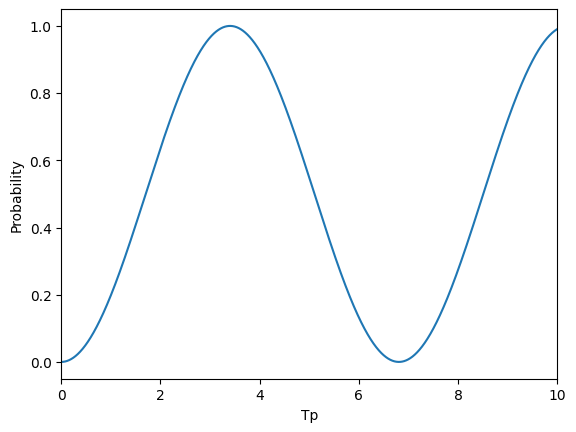

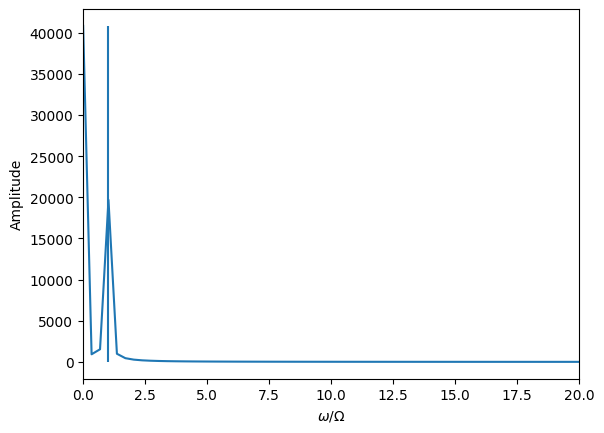

In [ ]:
fig, ax = plt.subplots()
ax.plot(t_vec/T, P)
ax.set_xlabel('Tp')
ax.set_ylabel('Probability')
ax.set_xlim(0, 10)

amp = np.fft.rfft(P)
freqs = np.fft.rfftfreq(len(t_vec), dt)*2*np.pi

fig, ax = plt.subplots()
ax.plot(freqs/omega1, np.abs(amp))
ax.vlines(1, 0, max(np.abs(amp)))
ax.set_xlabel('$\\omega/\\Omega$')
ax.set_ylabel('Amplitude')
ax.set_xlim(0, 10)

